In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
import numpy as np

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def linear(x):
    return x

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


In [26]:
# Inisialisasi bobot dan bias dengan Xavier Initialization
def initialize_weights(input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size):
    np.random.seed(42)
    weights_input_hidden = np.random.randn(input_size, hidden_size_1) * np.sqrt(1 / input_size)
    bias_hidden_1 = np.zeros((1, hidden_size_1))

    weights_hidden_2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(1 / hidden_size_1)
    bias_hidden_2 = np.zeros((1, hidden_size_2))

    weights_hidden_3 = np.random.randn(hidden_size_2, hidden_size_3) * np.sqrt(1 / hidden_size_2)
    bias_hidden_3 = np.zeros((1, hidden_size_3))

    weights_hidden_output = np.random.randn(hidden_size_3, output_size) * np.sqrt(1 / hidden_size_3)
    bias_output = np.zeros((1, output_size))

    return weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output

# Derivative of Tanh activation function
def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

# Training model BPNN dengan SGD (tanpa mini-batch)
def train_bpnn_sgd(X_train, y_train, X_val, y_val, epochs=200, learning_rate=0.001):
    input_size = X_train.shape[1]  # Sudah dalam bentuk (samples, 300)
    hidden_size_1 = 128
    hidden_size_2 = 64
    hidden_size_3 = 32
    output_size = 1

    # Inisialisasi bobot dan bias
    weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output = initialize_weights(
        input_size, hidden_size_1, hidden_size_2, hidden_size_3, output_size)

    losses_train = []
    losses_val = []

    # Training loop
    for epoch in range(epochs):
        total_loss = 0

        for i in range(len(X_train)):
            # Forward pass
            x = X_train[i].reshape(1, -1)  # (1, 300)
            y = y_train[i].reshape(1, -1)  # (1, 1)

            hidden_input_1 = np.dot(x, weights_input_hidden) + bias_hidden_1
            hidden_output_1 = np.tanh(hidden_input_1)

            hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
            hidden_output_2 = np.tanh(hidden_input_2)

            hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
            hidden_output_3 = np.tanh(hidden_input_3)

            output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
            y_pred = linear(output_input)

            # Hitung loss
            loss = mse_loss(y, y_pred)
            total_loss += loss

            # Backpropagation
            error_output = y_pred - y
            grad_weights_output = np.dot(hidden_output_3.T, error_output)
            grad_bias_output = error_output

            error_hidden_3 = np.dot(error_output, weights_hidden_output.T) * tanh_derivative(hidden_input_3)
            grad_weights_hidden_3 = np.dot(hidden_output_2.T, error_hidden_3)
            grad_bias_hidden_3 = error_hidden_3

            error_hidden_2 = np.dot(error_hidden_3, weights_hidden_3.T) * tanh_derivative(hidden_input_2)
            grad_weights_hidden_2 = np.dot(hidden_output_1.T, error_hidden_2)
            grad_bias_hidden_2 = error_hidden_2

            error_hidden_1 = np.dot(error_hidden_2, weights_hidden_2.T) * tanh_derivative(hidden_input_1)
            grad_weights_hidden_1 = np.dot(x.T, error_hidden_1)
            grad_bias_hidden_1 = error_hidden_1

            # Update bobot dan bias (SGD)
            weights_hidden_output -= learning_rate * grad_weights_output
            bias_output -= learning_rate * grad_bias_output

            weights_hidden_3 -= learning_rate * grad_weights_hidden_3
            bias_hidden_3 -= learning_rate * grad_bias_hidden_3

            weights_hidden_2 -= learning_rate * grad_weights_hidden_2
            bias_hidden_2 -= learning_rate * grad_bias_hidden_2

            weights_input_hidden -= learning_rate * grad_weights_hidden_1
            bias_hidden_1 -= learning_rate * grad_bias_hidden_1

        # Validasi loss
        hidden_input_1 = np.dot(X_val, weights_input_hidden) + bias_hidden_1
        hidden_output_1 = np.tanh(hidden_input_1)

        hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
        hidden_output_2 = np.tanh(hidden_input_2)

        hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
        hidden_output_3 = np.tanh(hidden_input_3)

        output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
        y_val_pred = linear(output_input)

        val_loss = mse_loss(y_val, y_val_pred.flatten())

        # Simpan loss setiap epoch
        losses_train.append(total_loss / len(X_train))
        losses_val.append(val_loss)

        # Print setiap 50 epoch
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train Loss = {losses_train[-1]}, Val Loss = {val_loss}")

    # Plot loss function
    plt.plot(losses_train, label='Train Loss')
    plt.plot(losses_val, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Loss Function During Training (SGD, 3 Hidden Layers)')
    plt.legend()
    plt.show()

    return weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output

In [27]:
# Load the dataset
dataset_path = "dataset.csv"
df = pd.read_csv(dataset_path)

# Display the first few rows to understand its structure
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,9/29/2005,432.588074,436.787964,407.388763,432.588074,304.904572,76180670.0
1,9/30/2005,457.787384,457.787384,432.588074,457.787384,322.666016,105493978.0
2,10/3/2005,470.387024,474.586914,440.987854,470.387024,331.546692,59712955.0
3,10/4/2005,474.586914,482.986694,466.187164,474.586914,334.506927,56236668.0
4,10/5/2005,482.986694,482.986694,466.187164,482.986694,340.427429,31319315.0


In [28]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Konversi kolom Date ke format datetime dan sort berdasarkan tanggal
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Pilih fitur (X) dan target (y)
feature_columns = ['Adj Close']
target_column = 'Adj Close'

# Normalisasi data menggunakan MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[feature_columns]), columns=feature_columns)

# **Sliding Window Method**: Menggunakan 50 hari sebelumnya untuk memprediksi hari ke-51
window_size = 50  # Panjang window

# Buat dataset dengan sliding window
X_seq, y_seq = [], []
for i in range(len(df_scaled) - window_size):
    X_seq.append(df_scaled.iloc[i:i+window_size].values)  # 50 hari terakhir sebagai input
    y_seq.append(df_scaled.iloc[i+window_size][target_column])  # Harga Close pada hari ke-(50+1)

X_seq = np.array(X_seq)  # Shape: (samples, 50, 6)
y_seq = np.array(y_seq)  # Shape: (samples,)

# Bagi dataset menjadi Train (70%), Validation (15%), dan Test (15%)
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.3, shuffle=False)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Flattening data setelah split
x_train = X_train_raw.reshape(X_train_raw.shape[0], -1)  # (2630, 50*6)
x_val = X_val_raw.reshape(X_val_raw.shape[0], -1)        # (564, 50*6)
x_test = X_test_raw.reshape(X_test_raw.shape[0], -1)     # (564, 50*6)


In [29]:
data = pd.DataFrame(x_train)
data

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.008410,0.014515,0.017567,0.018584,0.020619,0.016550,0.017567,0.016550,0.016550,0.017567,...,0.014515,0.019602,0.021637,0.022654,0.021637,0.022654,0.020619,0.020619,0.030793,0.051142
1,0.014515,0.017567,0.018584,0.020619,0.016550,0.017567,0.016550,0.016550,0.017567,0.018584,...,0.019602,0.021637,0.022654,0.021637,0.022654,0.020619,0.020619,0.030793,0.051142,0.051142
2,0.017567,0.018584,0.020619,0.016550,0.017567,0.016550,0.016550,0.017567,0.018584,0.018584,...,0.021637,0.022654,0.021637,0.022654,0.020619,0.020619,0.030793,0.051142,0.051142,0.040968
3,0.018584,0.020619,0.016550,0.017567,0.016550,0.016550,0.017567,0.018584,0.018584,0.018584,...,0.022654,0.021637,0.022654,0.020619,0.020619,0.030793,0.051142,0.051142,0.040968,0.035881
4,0.020619,0.016550,0.017567,0.016550,0.016550,0.017567,0.018584,0.018584,0.018584,0.017567,...,0.021637,0.022654,0.020619,0.020619,0.030793,0.051142,0.051142,0.040968,0.035881,0.033846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,0.121907,0.120228,0.121907,0.121907,0.130303,0.130303,0.128623,0.148773,0.145415,0.140377,...,0.178998,0.178998,0.177319,0.177319,0.175640,0.172281,0.170602,0.163886,0.165565,0.155490
2626,0.120228,0.121907,0.121907,0.130303,0.130303,0.128623,0.148773,0.145415,0.140377,0.133661,...,0.178998,0.177319,0.177319,0.175640,0.172281,0.170602,0.163886,0.165565,0.155490,0.157169
2627,0.121907,0.121907,0.130303,0.130303,0.128623,0.148773,0.145415,0.140377,0.133661,0.137019,...,0.177319,0.177319,0.175640,0.172281,0.170602,0.163886,0.165565,0.155490,0.157169,0.167244
2628,0.121907,0.130303,0.130303,0.128623,0.148773,0.145415,0.140377,0.133661,0.137019,0.157169,...,0.177319,0.175640,0.172281,0.170602,0.163886,0.165565,0.155490,0.157169,0.167244,0.168923


In [30]:
data1 = pd.DataFrame(y_train)
data1

,0
0,0.051142
1,0.040968
2,0.035881
3,0.033846
4,0.041985
...,...
2625,0.157169
2626,0.167244
2627,0.168923
2628,0.163886


Epoch 0: Train Loss = 0.007573742872049079, Val Loss = 0.004058706040184082
Epoch 50: Train Loss = 0.0006580597534966832, Val Loss = 0.00018316181068240957
Epoch 100: Train Loss = 0.0004841644831912634, Val Loss = 0.00012861876337878824
Epoch 150: Train Loss = 0.0004099507328787707, Val Loss = 0.00010360688886537692


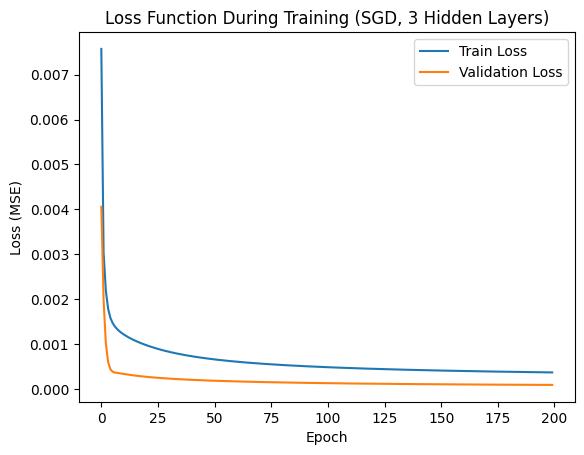

In [31]:
# Jalankan training dengan SGD dan 3 Hidden Layers
weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output = train_bpnn_sgd(x_train, y_train, x_val, y_val, epochs=200, learning_rate=0.001)

Any NaN in x_test before fixing? True
Any NaN in x_test after fixing? False
Checking y_pred_test and y_test values...
Min y_pred_test: 0.0064965283548014535 Max y_pred_test: 0.9006381535694352
Any NaN in predictions? False
Min y_test: 0.022668987646274508 Max y_test: 1.0
Any NaN in y_test? True

📊 Evaluasi Model :
✅ Mean Squared Error (MSE): 0.0005940508280315624
✅ Mean Absolute Error (MAE): 0.013006975211539264


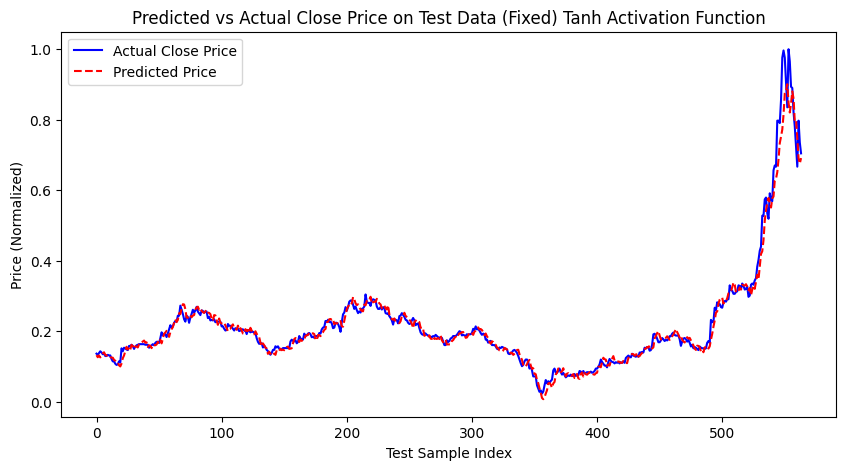

In [32]:
# Fungsi untuk melakukan prediksi dengan model yang telah dilatih
def predict_bpnn(X, weights_input_hidden, bias_hidden_1, weights_hidden_2, bias_hidden_2, 
                 weights_hidden_3, bias_hidden_3, weights_hidden_output, bias_output):
    """Melakukan prediksi menggunakan model BPNN yang telah dilatih"""
    hidden_input_1 = np.dot(X, weights_input_hidden) + bias_hidden_1
    hidden_output_1 = np.tanh(hidden_input_1)

    hidden_input_2 = np.dot(hidden_output_1, weights_hidden_2) + bias_hidden_2
    hidden_output_2 = np.tanh(hidden_input_2)

    hidden_input_3 = np.dot(hidden_output_2, weights_hidden_3) + bias_hidden_3
    hidden_output_3 = np.tanh(hidden_input_3)

    output_input = np.dot(hidden_output_3, weights_hidden_output) + bias_output
    y_pred = linear(output_input)

    return y_pred.flatten()  # Mengembalikan hasil prediksi dalam bentuk array 1D

# Periksa apakah x_test memiliki NaN sebelum melakukan prediksi
print("Any NaN in x_test before fixing?", np.isnan(x_test).any())
x_test = np.nan_to_num(x_test, nan=np.nanmedian(x_test))  # Ganti NaN dengan median dari x_test
print("Any NaN in x_test after fixing?", np.isnan(x_test).any())

# Melakukan prediksi pada data uji
y_pred_test = predict_bpnn(x_test, weights_input_hidden, bias_hidden_1, 
                           weights_hidden_2, bias_hidden_2, 
                           weights_hidden_3, bias_hidden_3, 
                           weights_hidden_output, bias_output)

# Periksa apakah ada NaN dalam hasil prediksi atau target
print("Checking y_pred_test and y_test values...")
print("Min y_pred_test:", np.nanmin(y_pred_test), "Max y_pred_test:", np.nanmax(y_pred_test))
print("Any NaN in predictions?", np.isnan(y_pred_test).any())

print("Min y_test:", np.nanmin(y_test), "Max y_test:", np.nanmax(y_test))
print("Any NaN in y_test?", np.isnan(y_test).any())

# Jika ada NaN atau Inf dalam prediksi, ganti dengan median dari y_test
y_pred_test = np.nan_to_num(y_pred_test, nan=np.nanmedian(y_test))
y_test = np.nan_to_num(y_test, nan=np.nanmedian(y_test))

# Evaluasi Model
mse_test = mse_loss(y_test, y_pred_test)  # Mean Squared Error
mae_test = np.mean(np.abs(y_test - y_pred_test))  # Mean Absolute Error

print(f"\n📊 Evaluasi Model :")
print(f"✅ Mean Squared Error (MSE): {mse_test}")
print(f"✅ Mean Absolute Error (MAE): {mae_test}")

# Plot Prediksi vs Aktual
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual Close Price", color='blue')
plt.plot(y_pred_test, label="Predicted Price", color='red', linestyle='dashed')
plt.xlabel("Test Sample Index")
plt.ylabel("Price (Normalized)")
plt.title("Predicted vs Actual Close Price on Test Data (Fixed) Tanh Activation Function")
plt.legend()
plt.show()


📊 Evaluasi Model setelah Denormalisasi:
✅ Mean Squared Error (MSE) dalam skala asli: 5028.980404411042
✅ Mean Absolute Error (MAE) dalam skala asli: 37.8446489882728


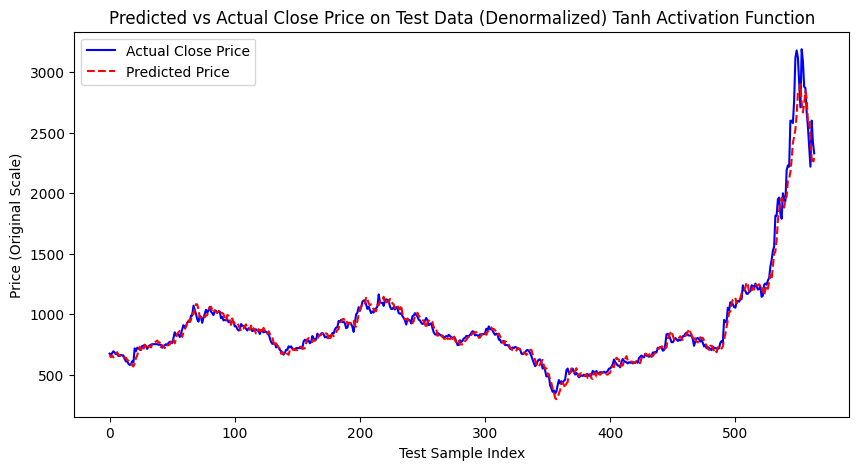

In [33]:
# Buat scaler khusus hanya untuk Close price
close_scaler = MinMaxScaler()
close_scaler.fit(df[['Adj Close']])  # Gunakan data asli sebelum normalisasi untuk mengetahui min-max yang benar

# Denormalisasi nilai prediksi dan nilai aktual
y_pred_test_original = close_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
y_test_original = close_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Evaluasi Model dalam Skala Asli
mse_test_original = mse_loss(y_test_original, y_pred_test_original)  # MSE dalam skala asli
mae_test_original = np.mean(np.abs(y_test_original - y_pred_test_original))  # MAE dalam skala asli

print(f"\n📊 Evaluasi Model setelah Denormalisasi:")
print(f"✅ Mean Squared Error (MSE) dalam skala asli: {mse_test_original}")
print(f"✅ Mean Absolute Error (MAE) dalam skala asli: {mae_test_original}")

# Plot Prediksi vs Aktual dalam Skala Asli
plt.figure(figsize=(10,5))
plt.plot(y_test_original, label="Actual Close Price", color='blue')
plt.plot(y_pred_test_original, label="Predicted Price", color='red', linestyle='dashed')
plt.xlabel("Test Sample Index")
plt.ylabel("Price (Original Scale)")
plt.title("Predicted vs Actual Close Price on Test Data (Denormalized) Tanh Activation Function")
plt.legend()
plt.show()
